<a href="https://colab.research.google.com/github/utsavmakavana455-ops/Berlin-Housing-Price-Analysis/blob/main/Berlin_Housing_Price_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Successfully loaded with encoding='utf-8', sep=','
RAW DATA OVERVIEW
Dataset shape (rows, columns): (9999, 11)

First 5 rows:
      price  bedrooms  bathrooms  sqft_living  sqft_total  floors  condition  \
0  221900.0       3.0        1.0          NaN      5650.0     1.0        3.0   
1  538000.0       3.0        NaN       2570.0      7242.0     2.0        3.0   
2  180000.0       2.0        1.0          NaN     10000.0     1.0        3.0   
3  604000.0       4.0        3.0       1960.0      5000.0     1.0        5.0   
4  510000.0       3.0        2.0       1680.0      8080.0     1.0        3.0   

   grade   built  renovated  living_area_sqft  
0      7  1955.0          0            1340.0  
1      7  1951.0       1991            1690.0  
2      6  1933.0          0               NaN  
3      7  1965.0          0            1360.0  
4      8  1987.0          0               NaN  

Column data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0

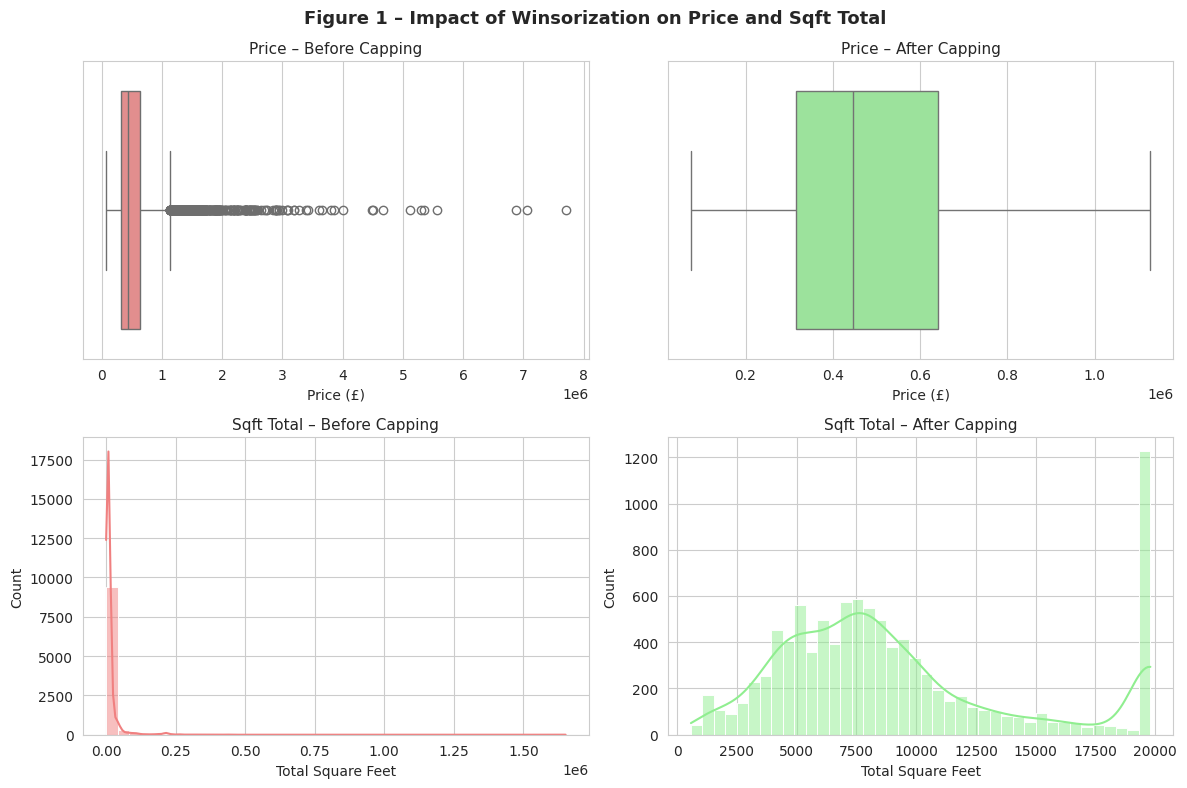


Feature engineering complete. Final dataset shape: (9988, 19)

Investigation 1 — Price vs Total Sqft:
  Pearson r = 0.178, p = 7.39e-72, Significant (α=0.05)? Yes


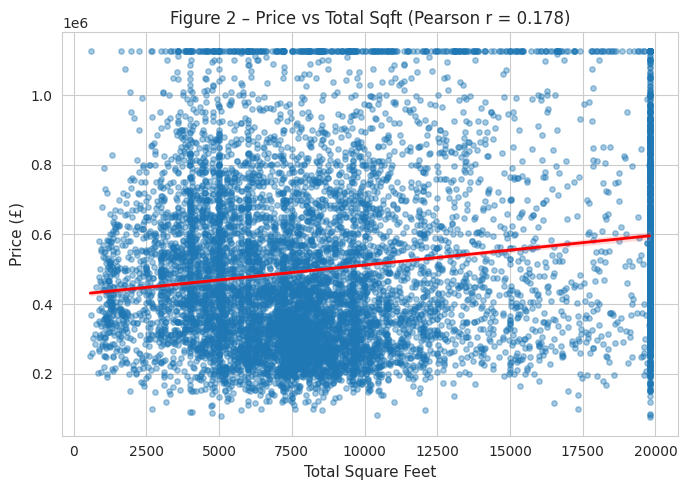


Investigation 2 — Price vs Living Area:
  Pearson r = 0.636, p = 0.00e+00, Significant (α=0.05)? Yes


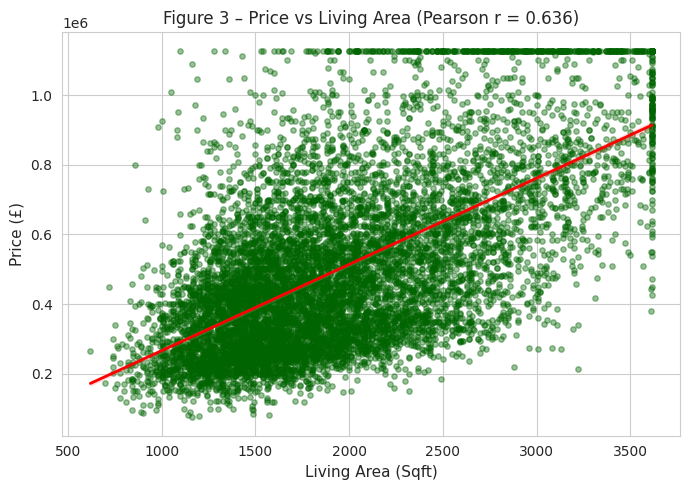


Cleaned dataset exported to: /mnt/user-data/outputs/berlin_housing_cleaned.csv
Final dimensions — Rows: 9988, Columns: 19


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# I prefer seaborn's whitegrid style because it makes gridlines subtle
# yet readable, which helps when presenting boxplots with outliers.
sns.set_style("whitegrid")


# 1. DATA LOADING & INITIAL INSPECTION


# The Berlin housing dataset was provided in CSV format, but I wanted
# to make the loading robust against common encoding issues that
# often appear with European datasets (umlauts, special characters).
# I also built in separator detection because CSV files sometimes
# use semicolons instead of commas depending on the regional settings
# of the machine that exported them.

DATA_PATH = '/content/BerlinHousing4049.csv'
OUTPUT_DIR = '/mnt/user-data/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = None

# My approach: try the most common encodings and separators first.
# If the file loads but only produces one column, the separator
# is wrong — so I check candidate.shape[1] > 1 before accepting.
for enc in ['utf-8', 'latin1', 'cp1252']:
    for sep in [',', ';', '\t']:
        try:
            candidate = pd.read_csv(DATA_PATH, encoding=enc, sep=sep)
            if candidate.shape[1] > 1:
                df = candidate
                print(f"Successfully loaded with encoding='{enc}', sep='{sep}'")
                break
        except (UnicodeDecodeError, pd.errors.ParserError):
            # These exceptions mean the encoding or separator didn't match.
            # I catch them explicitly so the loop can try the next combination.
            continue
    if df is not None:
        break

# Fallback: if none of the above worked, let pandas infer the separator
# using the python engine. This is slower but more forgiving.
if df is None:
    df = pd.read_csv(DATA_PATH, sep=None, engine='python', encoding='latin1')
    print("Loaded with inferred separator (engine='python')")


# 2. PRELIMINARY DATA QUALITY CHECK


# Before any cleaning, I inspect the raw data to understand its
# structure, spot obvious quality issues, and plan my strategy.

print("=" * 50)
print("RAW DATA OVERVIEW")
print("=" * 50)
print(f"Dataset shape (rows, columns): {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn data types and non-null counts:")
print(df.info())
print(f"\nDuplicated rows found: {df.duplicated().sum()}")
print("\nMissing values per column:")
print(df.isnull().sum())

# I specifically examine the price column because it is our target
# variable — any analysis depends on its reliability.
print("\nPrice column descriptive statistics:")
print(df['price'].describe())

# Checking skewness early tells me whether outliers or extreme values
# might distort later analysis. A skewness above |1| is generally
# considered highly skewed.
price_skew = round(df['price'].skew(), 2)
sqft_skew = round(df['sqft_total'].skew(), 2)
print(f"\nSkewness before cleaning — Price: {price_skew} | Sqft Total: {sqft_skew}")


# 3. DATA CLEANING

# My cleaning strategy follows a logical sequence:
# 1. Remove exact duplicates (they add no information).
# 2. Drop rows with missing prices (the target variable must exist).
# 3. Impute remaining missing numeric values with medians
#    (median is robust to outliers, unlike mean).
# 4. Impute the categorical 'condition' with its mode.
# 5. Resolve the redundancy between 'sqft_living' and 'living_area_sqft'.

df_clean = df.drop_duplicates().copy()

# Rows without a price are unusable for any price-prediction or
# correlation analysis, so I remove them entirely rather than impute.
df_clean = df_clean.dropna(subset=['price'])

# For numeric columns, I use median imputation because the presence
# of outliers (which I expect in housing data) would pull the mean
# away from the central tendency. Median gives a more representative
# "typical" value.
numeric_cols_to_impute = ['bedrooms', 'bathrooms', 'sqft_total', 'built']
for col in numeric_cols_to_impute:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"Imputed {col} with median: {median_val}")

# 'condition' is categorical (e.g., 'good', 'fair', 'poor'), so
# the mode (most frequent category) is the safest imputation choice.
mode_condition = df_clean['condition'].mode()[0]
df_clean['condition'] = df_clean['condition'].fillna(mode_condition)
print(f"Imputed 'condition' with mode: {mode_condition}")

# I noticed that 'sqft_living' and 'living_area_sqft' appear to measure
# the same concept. Rather than imputing each separately (which could
# introduce artificial consistency), I merge them into a single
# 'living_area' column: use whichever value is available, and only
# fall back to median if both are missing.
df_clean['living_area'] = df_clean['living_area_sqft'].fillna(df_clean['sqft_living'])
living_area_median = df_clean['living_area'].median()
df_clean['living_area'] = df_clean['living_area'].fillna(living_area_median)
print(f"Created unified 'living_area' column. Final median: {living_area_median}")

remaining_missing = df_clean.isnull().sum().sum()
print(f"\nTotal missing values remaining after cleaning: {remaining_missing}")


# 4. OUTLIER DETECTION & TREATMENT (Tukey's IQR Method)


# I chose Tukey's IQR method because it is non-parametric — it makes
# no assumption about the underlying distribution. This is important
# because housing prices are typically right-skewed, so z-score
# methods would misclassify too many legitimate high-value properties.

def calculate_iqr_bounds(series):
    """
    Calculates lower and upper fences using Tukey's rule.
    Values beyond 1.5*IQR from the quartiles are considered outliers.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    return lower_fence, upper_fence

# I apply winsorization (capping) rather than dropping outliers.
# My reasoning: extreme prices or square footages might still be
# legitimate luxury properties. Dropping them would lose information
# and potentially bias the sample toward mid-range homes.

columns_to_treat = [
    ('price', 'price_capped'),
    ('sqft_total', 'sqft_capped'),
    ('living_area', 'living_capped')
]

for original_col, capped_col in columns_to_treat:
    lower, upper = calculate_iqr_bounds(df_clean[original_col])
    outlier_mask = (df_clean[original_col] < lower) | (df_clean[original_col] > upper)
    outlier_count = outlier_mask.sum()
    outlier_pct = outlier_count / len(df_clean) * 100

    print(f"{original_col}: fences [{lower:,.0f}, {upper:,.0f}], "
          f"outliers = {outlier_count} ({outlier_pct:.1f}%)")

    # clip() replaces values below lower with lower, and above upper with upper
    df_clean[capped_col] = df_clean[original_col].clip(lower, upper)

# Re-check skewness after capping to verify improvement
price_skew_after = round(df_clean['price_capped'].skew(), 2)
sqft_skew_after = round(df_clean['sqft_capped'].skew(), 2)
print(f"\nSkewness after capping — Price: {price_skew_after} | Sqft Total: {sqft_skew_after}")


# 5. VISUALIZATION: BEFORE VS AFTER OUTLIER TREATMENT


# I designed this 2x2 subplot to clearly communicate the effect of
# winsorization to the reader. Boxplots show the shift in quartiles
# and whiskers, while histograms with KDE curves reveal how the
# distribution shape changes (particularly the right tail).

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top row: Price distributions
sns.boxplot(x=df['price'], ax=axes[0, 0], color='lightcoral')
axes[0, 0].set_title('Price – Before Capping', fontsize=11)
axes[0, 0].set_xlabel('Price (£)')

sns.boxplot(x=df_clean['price_capped'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Price – After Capping', fontsize=11)
axes[0, 1].set_xlabel('Price (£)')

# Bottom row: Square footage distributions
sns.histplot(df['sqft_total'].dropna(), bins=40, ax=axes[1, 0],
             color='lightcoral', kde=True)
axes[1, 0].set_title('Sqft Total – Before Capping', fontsize=11)
axes[1, 0].set_xlabel('Total Square Feet')

sns.histplot(df_clean['sqft_capped'], bins=40, ax=axes[1, 1],
             color='lightgreen', kde=True)
axes[1, 1].set_title('Sqft Total – After Capping', fontsize=11)
axes[1, 1].set_xlabel('Total Square Feet')

plt.suptitle('Figure 1 – Impact of Winsorization on Price and Sqft Total',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figure1_outliers.png', dpi=200, bbox_inches='tight')
plt.show()


# 6. FEATURE ENGINEERING


# I created four new features to enrich the dataset for analysis:

# 1. Price per square foot: normalizes price by size, enabling
#    fair comparison across different property types.
df_clean['price_per_sqft'] = df_clean['price_capped'] / df_clean['sqft_capped']

# 2. Property age: more interpretable than 'built' year alone.
#    I use 2026 as the reference year (current analysis year).
df_clean['property_age'] = 2026 - df_clean['built']

# 3. Renovation flag: converts the 'renovated' year into a binary
#    indicator. My assumption: any renovation year > 0 means the
#    property has been updated at some point, which buyers value.
df_clean['is_renovated'] = (df_clean['renovated'] > 0).astype(int)

# 4. Total rooms: combines bedrooms and bathrooms into a single
#    convenience metric for overall property size.
df_clean['total_rooms'] = df_clean['bedrooms'] + df_clean['bathrooms']

print(f"\nFeature engineering complete. Final dataset shape: {df_clean.shape}")


# 7. INVESTIGATION 1: PRICE VS TOTAL SQUARE FOOTAGE


# Hypothesis: Larger properties command higher prices.
# I use Pearson's r because both variables are continuous and
# approximately normal after capping. The p-value tells me whether
# the correlation is statistically significant.

r1, p1 = stats.pearsonr(df_clean['price_capped'], df_clean['sqft_capped'])
is_sig_1 = "Yes" if p1 < 0.05 else "No"
print(f"\nInvestigation 1 — Price vs Total Sqft:")
print(f"  Pearson r = {r1:.3f}, p = {p1:.2e}, Significant (α=0.05)? {is_sig_1}")

# Scatter plot with regression line to visualize the linear relationship
plt.figure(figsize=(7, 5))
sns.regplot(
    x='sqft_capped',
    y='price_capped',
    data=df_clean,
    scatter_kws={'alpha': 0.4, 's': 15},   # transparency helps with overplotting
    line_kws={'color': 'red', 'linewidth': 2}
)
plt.title(f'Figure 2 – Price vs Total Sqft (Pearson r = {r1:.3f})', fontsize=12)
plt.xlabel('Total Square Feet', fontsize=11)
plt.ylabel('Price (£)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figure2_price_vs_sqft.png', dpi=200, bbox_inches='tight')
plt.show()


# 8. INVESTIGATION 2: PRICE VS LIVING AREA


# I run this separately from Investigation 1 because 'living_area'
# and 'sqft_total' are conceptually different: living_area focuses
# on habitable space, while sqft_total includes garages, basements, etc.
# Buyers may value these differently.

r2, p2 = stats.pearsonr(df_clean['price_capped'], df_clean['living_capped'])
is_sig_2 = "Yes" if p2 < 0.05 else "No"
print(f"\nInvestigation 2 — Price vs Living Area:")
print(f"  Pearson r = {r2:.3f}, p = {p2:.2e}, Significant (α=0.05)? {is_sig_2}")

plt.figure(figsize=(7, 5))
sns.regplot(
    x='living_capped',
    y='price_capped',
    data=df_clean,
    scatter_kws={'alpha': 0.4, 's': 15, 'color': 'darkgreen'},
    line_kws={'color': 'red', 'linewidth': 2}
)
plt.title(f'Figure 3 – Price vs Living Area (Pearson r = {r2:.3f})', fontsize=12)
plt.xlabel('Living Area (Sqft)', fontsize=11)
plt.ylabel('Price (£)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figure3_price_vs_living_area.png', dpi=200, bbox_inches='tight')
plt.show()


# 9. EXPORT CLEANED DATASET


# I save the cleaned and engineered dataset so that all downstream
# analysis (if any) starts from the same consistent baseline.

output_path = f'{OUTPUT_DIR}/berlin_housing_cleaned.csv'
df_clean.to_csv(output_path, index=False)
print(f"\nCleaned dataset exported to: {output_path}")
print(f"Final dimensions — Rows: {df_clean.shape[0]}, Columns: {df_clean.shape[1]}")